# Практическая работа 3
## Введение в Apache Spark: RDD, DataFrame, Spark SQL

---
## 1. Подготовка окружения

### 1.1 Установка зависимостей

In [1]:
import subprocess, sys

# Установка необходимых пакетов (раскомментировать при первом запуске в Colab)
# !apt-get install -y openjdk-8-jdk-headless -qq > /dev/null
# !pip install -q pyspark findspark pandas numpy

for pkg in ['pyspark', 'findspark', 'pandas', 'numpy', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Зависимости установлены.')

Зависимости установлены.


In [2]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройка JAVA_HOME для локального запуска
# В Google Colab это не нужно после установки openjdk
for candidate in [
    '/usr/lib/jvm/java-21-openjdk-amd64',
    '/usr/lib/jvm/java-11-openjdk-amd64',
    '/usr/lib/jvm/java-8-openjdk-amd64',
    '/usr/local/lib/jvm',
]:
    if os.path.isdir(candidate):
        os.environ.setdefault('JAVA_HOME', candidate)
        break

print('JAVA_HOME:', os.environ.get('JAVA_HOME', 'не задан'))

import pyspark
print(f'PySpark {pyspark.__version__}')

JAVA_HOME: /usr/lib/jvm/java-21-openjdk-amd64
PySpark 4.1.1


### 1.2 Создание SparkSession

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('Practicum3_Spark_Agro')
    .master('local[*]')          # локальный режим, все ядра
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.ui.showConsoleProgress', 'false')
    .config('spark.driver.memory', '1g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

print(f'Spark версия: {spark.version}')
print(f'Spark master: {spark.sparkContext.master}')
print(f'Количество ядер: {spark.sparkContext.defaultParallelism}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/20 08:44:39 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/05/20 08:44:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/20 08:44:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark версия: 4.1.1
Spark master: local[*]
Количество ядер: 1


---
## 2. Работа с RDD (Resilient Distributed Datasets)

### 2.1 Основные концепции RDD

RDD - базовая абстракция Spark:
- **Resilient** - отказоустойчивость через lineage (граф вычислений);
- **Distributed** - данные логически разделены на партиции;
- **Immutable** - операции создают новые RDD, исходный не изменяется.

Типы операций:
- **Transformations** (ленивые): `map`, `filter`, `flatMap`, `reduceByKey`;
- **Actions** (запускают вычисления): `collect`, `count`, `reduce`, `take`.

In [4]:
sc = spark.sparkContext  # SparkContext для работы с RDD

# Создание RDD из коллекции Python
numbers = list(range(1, 21))
rdd = sc.parallelize(numbers, numSlices=4)

print('Количество элементов:', rdd.count())
print('Первые 5 элементов:', rdd.take(5))
print('Число партиций:', rdd.getNumPartitions())

Количество элементов: 20


Первые 5 элементов: [1, 2, 3, 4, 5]
Число партиций: 4


In [5]:
# 2.3 Операции map и filter
# Задача: оставить только чётные числа и возвести их в квадрат

even_squares_rdd = (
    rdd
    .filter(lambda x: x % 2 == 0)
    .map(lambda x: x * x)
)

result = even_squares_rdd.collect()
print('Квадраты чётных чисел:', result)

Квадраты чётных чисел: [4, 16, 36, 64, 100, 144, 196, 256, 324, 400]


In [6]:
# 2.4 Операция reduce
# Задача: посчитать сумму квадратов чётных чисел

from operator import add

sum_even_squares = even_squares_rdd.reduce(add)
print('Сумма квадратов чётных чисел:', sum_even_squares)
# Проверка: 4+16+36+64+100+144+196+256+324+400 = 1540
print('Проверка (Python):', sum(x*x for x in range(1,21) if x%2==0))

Сумма квадратов чётных чисел: 1540
Проверка (Python): 1540


In [7]:
# 2.5 Задания для самостоятельной работы (RDD)

# 2.5.1 Количество чисел, делящихся на 3 в диапазоне 1-20
count_div3 = rdd.filter(lambda x: x % 3 == 0).count()
print(f'2.5.1 Чисел, делящихся на 3 в 1-20: {count_div3}')

# 2.5.2 Максимальное и минимальное значение через reduce
max_value = rdd.reduce(lambda a, b: a if a > b else b)
min_value = rdd.reduce(lambda a, b: a if a < b else b)
print(f'2.5.2 Максимум: {max_value},  Минимум: {min_value}')

# 2.5.3 RDD из слов, общее количество символов
words = ['spark', 'rdd', 'dataframe', 'sql']
words_rdd = sc.parallelize(words)
total_chars = words_rdd.map(lambda w: len(w)).reduce(add)
print(f'2.5.3 Слова: {words}')
print(f'      Общее количество символов: {total_chars}')

2.5.1 Чисел, делящихся на 3 в 1-20: 6


2.5.2 Максимум: 20,  Минимум: 1


2.5.3 Слова: ['spark', 'rdd', 'dataframe', 'sql']
      Общее количество символов: 20


---
## 3. Генерация синтетического агро-датасета

### 3.1 Описание датасета

Моделируем показания сенсоров, установленных на полях:

| Колонка | Описание |
|---|---|
| `sensor_id` | идентификатор сенсора (например, `field_3_s1`) |
| `timestamp` | время измерения |
| `field_id` | идентификатор поля (`field_1`, `field_2`, ...) |
| `soil_temp` | температура почвы (°C) |
| `soil_moisture` | влажность почвы (условные %) |
| `air_temp` | температура воздуха (°C) |

In [8]:
# 3.2 Генерация данных в pandas
np.random.seed(42)

n_fields         = 15
sensors_per_field = 2
days             = pd.date_range('2024-04-01', periods=10, freq='D')
freq             = '1h'

fields = [f'field_{i}' for i in range(1, n_fields + 1)]
rows   = []

for field_id in fields:
    for sensor_idx in range(1, sensors_per_field + 1):
        sensor_id      = f'{field_id}_s{sensor_idx}'
        base_soil_temp = np.random.uniform(8, 18)
        base_air_temp  = np.random.uniform(10, 20)
        base_moisture  = np.random.uniform(25, 45)

        for day in days:
            times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)

            soil_temp  = (base_soil_temp
                          + 5 * np.sin(2 * np.pi * times.hour / 24)
                          + np.random.normal(0, 1, len(times)))
            air_temp   = (base_air_temp
                          + 8 * np.sin(2 * np.pi * times.hour / 24)
                          + np.random.normal(0, 1.5, len(times)))
            soil_moist = base_moisture + np.random.normal(0, 3, len(times))

            # Имитируем засуху на части полей
            if field_id in ['field_3', 'field_7', 'field_12']:
                soil_moist -= np.random.uniform(5, 12)

            for t, st, sm, at in zip(times, soil_temp, soil_moist, air_temp):
                rows.append({
                    'sensor_id':    sensor_id,
                    'timestamp':    t,
                    'field_id':     field_id,
                    'soil_temp':    round(float(st), 1),
                    'soil_moisture': round(float(max(sm, 0)), 1),
                    'air_temp':     round(float(at), 1),
                })

pdf = pd.DataFrame(rows)
csv_path = 'agro_sensors.csv'
pdf.to_csv(csv_path, index=False)

print(f'Датасет создан: {len(pdf):,} строк')
print(f'Файл сохранён: {csv_path}')
print(f'Поля: {n_fields},  Сенсоров: {n_fields * sensors_per_field},'
      f'  Дней: {len(days)}')
print()
print('Статистика по числовым колонкам:')
print(pdf[['soil_temp', 'soil_moisture', 'air_temp']].describe().round(2))
print()
print(pdf.head(10))

/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date

Датасет создан: 7,200 строк
Файл сохранён: agro_sensors.csv
Поля: 15,  Сенсоров: 30,  Дней: 10

Статистика по числовым колонкам:
       soil_temp  soil_moisture  air_temp
count    7200.00        7200.00   7200.00
mean       12.58          33.97     14.28
std         4.72           8.03      6.67
min         1.10           9.50     -1.00
25%         9.20          27.90      8.90
50%        12.60          34.00     14.30
75%        16.10          40.60     19.30
max        24.80          56.00     31.20

    sensor_id           timestamp field_id  soil_temp  soil_moisture  air_temp
0  field_1_s1 2024-04-01 00:00:00  field_1       10.6           42.3      19.9
1  field_1_s1 2024-04-01 01:00:00  field_1       13.4           41.9      20.6
2  field_1_s1 2024-04-01 02:00:00  field_1       14.5           39.0      22.0
3  field_1_s1 2024-04-01 03:00:00  field_1       16.3           37.8      24.9
4  field_1_s1 2024-04-01 04:00:00  field_1       15.5           35.1      25.6
5  field_1_s1 2024

/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date_range(day, day + pd.Timedelta('23H'), freq=freq)
/tmp/ipykernel_671/1841310280.py:20: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  times = pd.date

---
## 4. Загрузка агро-данных в Spark DataFrame

### 4.1 Чтение CSV в DataFrame

In [9]:
from pyspark.sql.types import (StructType, StructField,
                                StringType, DoubleType, TimestampType)

schema = StructType([
    StructField('sensor_id',    StringType(),    nullable=False),
    StructField('timestamp',    TimestampType(), nullable=False),
    StructField('field_id',     StringType(),    nullable=False),
    StructField('soil_temp',    DoubleType(),    nullable=False),
    StructField('soil_moisture', DoubleType(),   nullable=False),
    StructField('air_temp',     DoubleType(),    nullable=False),
])

df = (
    spark.read
    .option('header', 'true')
    .schema(schema)
    .csv(csv_path)
)

print('Схема DataFrame:')
df.printSchema()
print(f'Количество строк: {df.count():,}')
df.show(5, truncate=False)

Схема DataFrame:
root
 |-- sensor_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- field_id: string (nullable = true)
 |-- soil_temp: double (nullable = true)
 |-- soil_moisture: double (nullable = true)
 |-- air_temp: double (nullable = true)



Количество строк: 7,200


+----------+-------------------+--------+---------+-------------+--------+
|sensor_id |timestamp          |field_id|soil_temp|soil_moisture|air_temp|
+----------+-------------------+--------+---------+-------------+--------+
|field_1_s1|2024-04-01 00:00:00|field_1 |10.6     |42.3         |19.9    |
|field_1_s1|2024-04-01 01:00:00|field_1 |13.4     |41.9         |20.6    |
|field_1_s1|2024-04-01 02:00:00|field_1 |14.5     |39.0         |22.0    |
|field_1_s1|2024-04-01 03:00:00|field_1 |16.3     |37.8         |24.9    |
|field_1_s1|2024-04-01 04:00:00|field_1 |15.5     |35.1         |25.6    |
+----------+-------------------+--------+---------+-------------+--------+
only showing top 5 rows


In [10]:
# 4.2 Базовые операции с DataFrame
from pyspark.sql import functions as F

# Количество полей и сенсоров
n_fields_spark   = df.select('field_id').distinct().count()
n_sensors_spark  = df.select('sensor_id').distinct().count()

print(f'Число полей:   {n_fields_spark}')
print(f'Число сенсоров: {n_sensors_spark}')

# Диапазон времени
df.select(
    F.min('timestamp').alias('min_ts'),
    F.max('timestamp').alias('max_ts')
).show(truncate=False)

# Описательная статистика
df.describe('soil_temp', 'soil_moisture', 'air_temp').show(truncate=False)

Число полей:   15
Число сенсоров: 30


+-------------------+-------------------+
|min_ts             |max_ts             |
+-------------------+-------------------+
|2024-04-01 00:00:00|2024-04-10 23:00:00|
+-------------------+-------------------+



+-------+------------------+------------------+------------------+
|summary|soil_temp         |soil_moisture     |air_temp          |
+-------+------------------+------------------+------------------+
|count  |7200              |7200              |7200              |
|mean   |12.584611111111078|33.965513888888886|14.277847222222219|
|stddev |4.718382756819784 |8.027028821861084 |6.672776393850316 |
|min    |1.1               |9.5               |-1.0              |
|max    |24.8              |56.0              |31.2              |
+-------+------------------+------------------+------------------+



---
## 5. Трансформации DataFrame

### 5.1 Фильтрация данных

In [11]:
# Выбрать строки с очень низкой влажностью (soil_moisture < 15)
dry_measurements = df.filter(F.col('soil_moisture') < 15)

print(f'Измерений с очень низкой влажностью: {dry_measurements.count():,}')
dry_measurements.select('field_id', 'timestamp', 'soil_moisture') \
    .show(10, truncate=False)

Измерений с очень низкой влажностью: 45


+--------+-------------------+-------------+
|field_id|timestamp          |soil_moisture|
+--------+-------------------+-------------+
|field_3 |2024-04-01 01:00:00|12.4         |
|field_3 |2024-04-01 05:00:00|12.5         |
|field_3 |2024-04-01 07:00:00|13.2         |
|field_3 |2024-04-01 08:00:00|14.4         |
|field_3 |2024-04-02 07:00:00|14.9         |
|field_3 |2024-04-03 06:00:00|14.1         |
|field_3 |2024-04-04 00:00:00|12.9         |
|field_3 |2024-04-04 02:00:00|11.7         |
|field_3 |2024-04-04 06:00:00|14.0         |
|field_3 |2024-04-04 09:00:00|13.4         |
+--------+-------------------+-------------+
only showing top 10 rows


In [12]:
# 5.2 Добавление вычисляемых колонок
# - колонка date (день из timestamp)
# - флаг is_low_moisture (1, если влажность ниже порога 20)

df2 = df.withColumn('date', F.to_date('timestamp'))

df2 = df2.withColumn(
    'is_low_moisture',
    F.when(F.col('soil_moisture') < 20, F.lit(1)).otherwise(F.lit(0))
)

print('DataFrame с вычисляемыми колонками:')
df2.select('field_id', 'timestamp', 'date', 'soil_moisture', 'is_low_moisture') \
   .show(10, truncate=False)

DataFrame с вычисляемыми колонками:


+--------+-------------------+----------+-------------+---------------+
|field_id|timestamp          |date      |soil_moisture|is_low_moisture|
+--------+-------------------+----------+-------------+---------------+
|field_1 |2024-04-01 00:00:00|2024-04-01|42.3         |0              |
|field_1 |2024-04-01 01:00:00|2024-04-01|41.9         |0              |
|field_1 |2024-04-01 02:00:00|2024-04-01|39.0         |0              |
|field_1 |2024-04-01 03:00:00|2024-04-01|37.8         |0              |
|field_1 |2024-04-01 04:00:00|2024-04-01|35.1         |0              |
|field_1 |2024-04-01 05:00:00|2024-04-01|42.9         |0              |
|field_1 |2024-04-01 06:00:00|2024-04-01|39.1         |0              |
|field_1 |2024-04-01 07:00:00|2024-04-01|38.4         |0              |
|field_1 |2024-04-01 08:00:00|2024-04-01|43.2         |0              |
|field_1 |2024-04-01 09:00:00|2024-04-01|36.9         |0              |
+--------+-------------------+----------+-------------+---------

In [13]:
# 5.3 Задания для самостоятельной работы (трансформации)

# 5.3.1 Добавить temp_diff = air_temp - soil_temp
#        и посчитать среднюю разницу температур по каждому полю
df3 = df2.withColumn('temp_diff', F.col('air_temp') - F.col('soil_temp'))

avg_temp_diff = (
    df3.groupBy('field_id')
    .agg(F.avg('temp_diff').alias('avg_temp_diff'))
    .orderBy('field_id')
)
print('5.3.1 Средняя разница температур (air - soil) по полям:')
avg_temp_diff.show(truncate=False)

# 5.3.2 Доля измерений с низкой влажностью по каждому полю,
#        поля с наибольшей долей
low_moisture_share = (
    df2.groupBy('field_id')
    .agg(
        (F.sum('is_low_moisture') / F.count('*')).alias('low_moisture_share')
    )
    .orderBy(F.desc('low_moisture_share'))
)
print('5.3.2 Доля измерений с низкой влажностью (soil_moisture < 20):')
low_moisture_share.show(truncate=False)

5.3.1 Средняя разница температур (air - soil) по полям:


+--------+-------------------+
|field_id|avg_temp_diff      |
+--------+-------------------+
|field_1 |2.4410416666666634 |
|field_10|3.5152083333333333 |
|field_11|1.0185416666666665 |
|field_12|1.8475000000000004 |
|field_13|2.9704166666666656 |
|field_14|4.034374999999998  |
|field_15|2.7437500000000017 |
|field_2 |3.708750000000001  |
|field_3 |3.2066666666666666 |
|field_4 |-1.5156249999999996|
|field_5 |-2.6795833333333365|
|field_6 |-1.454999999999999 |
|field_7 |0.6572916666666679 |
|field_8 |5.182916666666668  |
|field_9 |-0.2777083333333327|
+--------+-------------------+

5.3.2 Доля измерений с низкой влажностью (soil_moisture < 20):


+--------+---------------------+
|field_id|low_moisture_share   |
+--------+---------------------+
|field_3 |0.44375              |
|field_7 |0.05                 |
|field_2 |0.027083333333333334 |
|field_12|0.022916666666666665 |
|field_5 |0.01875              |
|field_9 |0.008333333333333333 |
|field_13|0.0020833333333333333|
|field_15|0.0                  |
|field_8 |0.0                  |
|field_10|0.0                  |
|field_6 |0.0                  |
|field_1 |0.0                  |
|field_4 |0.0                  |
|field_11|0.0                  |
|field_14|0.0                  |
+--------+---------------------+



---
## 6. Агрегации: витрина «поле-день»

### 6.1 Построение витрины

In [14]:
agg_df = (
    df2
    .groupBy('field_id', 'date')
    .agg(
        F.count('*').alias('measurements'),
        F.avg('soil_temp').alias('avg_soil_temp'),
        F.avg('air_temp').alias('avg_air_temp'),
        F.avg('soil_moisture').alias('avg_moisture'),
        F.sum('is_low_moisture').alias('low_moisture_count'),
    )
    .orderBy('field_id', 'date')
)

# Округление
for col_name in ['avg_soil_temp', 'avg_air_temp', 'avg_moisture']:
    agg_df = agg_df.withColumn(col_name, F.round(col_name, 2))

print(f'Витрина field_id x date: {agg_df.count()} строк')
agg_df.show(20, truncate=False)

Витрина field_id x date: 150 строк


+--------+----------+------------+-------------+------------+------------+------------------+
|field_id|date      |measurements|avg_soil_temp|avg_air_temp|avg_moisture|low_moisture_count|
+--------+----------+------------+-------------+------------+------------+------------------+
|field_1 |2024-04-01|48          |12.98        |15.8        |41.64       |0                 |
|field_1 |2024-04-02|48          |13.26        |15.52       |42.2        |0                 |
|field_1 |2024-04-03|48          |13.63        |15.88       |41.95       |0                 |
|field_1 |2024-04-04|48          |13.21        |15.54       |42.72       |0                 |
|field_1 |2024-04-05|48          |13.33        |15.65       |42.02       |0                 |
|field_1 |2024-04-06|48          |13.43        |15.85       |41.86       |0                 |
|field_1 |2024-04-07|48          |12.97        |15.42       |41.94       |0                 |
|field_1 |2024-04-08|48          |13.0         |15.79       

In [15]:
# 6.2 Анализ риска засухи
# "Рисковый день" поля: avg_moisture < 20

risk_days_df = (
    agg_df
    .filter(F.col('avg_moisture') < 20)
    .groupBy('field_id')
    .agg(F.count('*').alias('risk_days'))
    .orderBy(F.desc('risk_days'))
)

print('Поля с рисковыми днями (avg_moisture < 20):')
risk_days_df.show(truncate=False)

# 6.3 Задания для самостоятельной работы (агрегации)

# 6.3.1 Минимальная и максимальная средняя влажность по дням для каждого поля
moisture_range = (
    agg_df.groupBy('field_id')
    .agg(
        F.min('avg_moisture').alias('min_daily_moisture'),
        F.max('avg_moisture').alias('max_daily_moisture'),
    )
    .orderBy('field_id')
)
print('6.3.1 Диапазон средней влажности по дням (для каждого поля):')
moisture_range.show(truncate=False)

# 6.3.2 Топ-5 полей с наименьшей средней влажностью по всей истории
top5_driest = (
    df2.groupBy('field_id')
    .agg(F.avg('soil_moisture').alias('overall_avg_moisture'))
    .orderBy('overall_avg_moisture')
    .limit(5)
)
print('6.3.2 Топ-5 самых сухих полей:')
top5_driest.show(truncate=False)

Поля с рисковыми днями (avg_moisture < 20):


+--------+---------+
|field_id|risk_days|
+--------+---------+
|field_3 |2        |
+--------+---------+

6.3.1 Диапазон средней влажности по дням (для каждого поля):


+--------+------------------+------------------+
|field_id|min_daily_moisture|max_daily_moisture|
+--------+------------------+------------------+
|field_1 |41.46             |42.72             |
|field_10|35.81             |36.94             |
|field_11|38.71             |40.44             |
|field_12|26.63             |32.06             |
|field_13|33.37             |34.64             |
|field_14|38.03             |39.08             |
|field_15|43.78             |44.69             |
|field_2 |34.34             |35.51             |
|field_3 |18.47             |24.56             |
|field_4 |35.41             |35.79             |
|field_5 |31.3              |32.64             |
|field_6 |34.0              |34.98             |
|field_7 |24.28             |29.5              |
|field_8 |31.7              |33.3              |
|field_9 |27.94             |29.12             |
+--------+------------------+------------------+

6.3.2 Топ-5 самых сухих полей:


+--------+--------------------+
|field_id|overall_avg_moisture|
+--------+--------------------+
|field_3 |20.889791666666657  |
|field_7 |26.75895833333334   |
|field_9 |28.595833333333356  |
|field_12|28.869791666666682  |
|field_5 |31.90041666666668   |
+--------+--------------------+



---
## 7. Spark SQL: временные представления

### 7.1 Регистрация временных представлений

In [16]:
df2.createOrReplaceTempView('sensor_readings')
agg_df.createOrReplaceTempView('field_day_metrics')

print('Временные представления зарегистрированы:')
spark.catalog.listTables()

Временные представления зарегистрированы:


[Table(name='field_day_metrics', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='sensor_readings', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [17]:
# 7.2 Пример SQL-запроса 1:
# Количество измерений и средняя влажность по полям

sql1 = """
SELECT
    field_id,
    COUNT(*)              AS total_measurements,
    ROUND(AVG(soil_moisture), 2) AS avg_moisture
FROM sensor_readings
GROUP BY field_id
ORDER BY avg_moisture
"""

print('SQL 1 - Средняя влажность по полям:')
spark.sql(sql1).show(truncate=False)

SQL 1 - Средняя влажность по полям:


+--------+------------------+------------+
|field_id|total_measurements|avg_moisture|
+--------+------------------+------------+
|field_3 |480               |20.89       |
|field_7 |480               |26.76       |
|field_9 |480               |28.6        |
|field_12|480               |28.87       |
|field_5 |480               |31.9        |
|field_8 |480               |32.86       |
|field_13|480               |33.98       |
|field_6 |480               |34.39       |
|field_2 |480               |34.79       |
|field_4 |480               |35.56       |
|field_10|480               |36.24       |
|field_14|480               |38.71       |
|field_11|480               |39.54       |
|field_1 |480               |41.97       |
|field_15|480               |44.42       |
+--------+------------------+------------+



In [18]:
# SQL-запрос 2: Поля с максимальным числом рисковых дней

sql2 = """
SELECT
    field_id,
    COUNT(*) AS risk_days
FROM field_day_metrics
WHERE avg_moisture < 20
GROUP BY field_id
ORDER BY risk_days DESC
"""

print('SQL 2 - Поля с максимальным числом рисковых дней:')
spark.sql(sql2).show(truncate=False)

SQL 2 - Поля с максимальным числом рисковых дней:


+--------+---------+
|field_id|risk_days|
+--------+---------+
|field_3 |2        |
+--------+---------+



In [19]:
# SQL-запрос 3: Топ-5 самых сухих дней для конкретного поля

sql3 = """
SELECT
    field_id,
    date,
    avg_moisture
FROM field_day_metrics
WHERE field_id = 'field_3'
ORDER BY avg_moisture ASC
LIMIT 5
"""

print('SQL 3 - Топ-5 самых сухих дней для field_3:')
spark.sql(sql3).show(truncate=False)

SQL 3 - Топ-5 самых сухих дней для field_3:


+--------+----------+------------+
|field_id|date      |avg_moisture|
+--------+----------+------------+
|field_3 |2024-04-04|18.47       |
|field_3 |2024-04-10|19.91       |
|field_3 |2024-04-05|20.02       |
|field_3 |2024-04-02|20.31       |
|field_3 |2024-04-08|20.47       |
+--------+----------+------------+



In [20]:
# 7.3 Задания для самостоятельной работы (SQL)

# 7.3.1 SQL-запрос: для каждого поля число дней,
#        средняя, минимальная и максимальная avg_moisture
sql_self1 = """
SELECT
    field_id,
    COUNT(DISTINCT date)               AS num_days,
    ROUND(AVG(avg_moisture), 2)        AS mean_moisture,
    ROUND(MIN(avg_moisture), 2)        AS min_moisture,
    ROUND(MAX(avg_moisture), 2)        AS max_moisture
FROM field_day_metrics
GROUP BY field_id
ORDER BY mean_moisture
"""
print('7.3.1 Статистика по дням и влажности для каждого поля:')
spark.sql(sql_self1).show(truncate=False)

# 7.3.2 Поля, у которых доля рисковых дней (avg_moisture < 20) > 50%
sql_self2 = """
SELECT
    field_id,
    COUNT(*) AS total_days,
    SUM(CASE WHEN avg_moisture < 20 THEN 1 ELSE 0 END) AS risk_days,
    ROUND(
        SUM(CASE WHEN avg_moisture < 20 THEN 1 ELSE 0 END) * 1.0 / COUNT(*),
    2) AS risk_ratio
FROM field_day_metrics
GROUP BY field_id
HAVING risk_ratio > 0.5
ORDER BY risk_ratio DESC
"""
print('7.3.2 Поля с долей рисковых дней > 50%:')
spark.sql(sql_self2).show(truncate=False)

7.3.1 Статистика по дням и влажности для каждого поля:


+--------+--------+-------------+------------+------------+
|field_id|num_days|mean_moisture|min_moisture|max_moisture|
+--------+--------+-------------+------------+------------+
|field_3 |10      |20.89        |18.47       |24.56       |
|field_7 |10      |26.76        |24.28       |29.5        |
|field_9 |10      |28.6         |27.94       |29.12       |
|field_12|10      |28.87        |26.63       |32.06       |
|field_5 |10      |31.9         |31.3        |32.64       |
|field_8 |10      |32.86        |31.7        |33.3        |
|field_13|10      |33.99        |33.37       |34.64       |
|field_6 |10      |34.39        |34.0        |34.98       |
|field_2 |10      |34.8         |34.34       |35.51       |
|field_4 |10      |35.56        |35.41       |35.79       |
|field_10|10      |36.24        |35.81       |36.94       |
|field_14|10      |38.71        |38.03       |39.08       |
|field_11|10      |39.55        |38.71       |40.44       |
|field_1 |10      |41.97        |41.46  

+--------+----------+---------+----------+
|field_id|total_days|risk_days|risk_ratio|
+--------+----------+---------+----------+
+--------+----------+---------+----------+



---
## 8. Сравнение DataFrame API и Spark SQL

### 8.1 Одна задача двумя способами

In [21]:
# Задача: посчитать число рисковых дней по полям

# --- DataFrame API ---
t0 = time.time()
df_api_result = (
    agg_df
    .filter(F.col('avg_moisture') < 20)
    .groupBy('field_id')
    .agg(F.count('*').alias('risk_days'))
    .orderBy('field_id')
)
df_api_result.collect()
t_api = time.time() - t0

# --- Spark SQL ---
t0 = time.time()
sql_result = spark.sql("""
    SELECT field_id, COUNT(*) AS risk_days
    FROM field_day_metrics
    WHERE avg_moisture < 20
    GROUP BY field_id
    ORDER BY field_id
""")
sql_result.collect()
t_sql = time.time() - t0

print('DataFrame API результат:')
df_api_result.show(truncate=False)

print('Spark SQL результат:')
sql_result.show(truncate=False)

print(f'DataFrame API: {t_api:.3f} сек')
print(f'Spark SQL:     {t_sql:.3f} сек')
print('(результаты идентичны, оба используют один и тот же Catalyst-оптимизатор)')

DataFrame API результат:


+--------+---------+
|field_id|risk_days|
+--------+---------+
|field_3 |2        |
+--------+---------+

Spark SQL результат:


+--------+---------+
|field_id|risk_days|
+--------+---------+
|field_3 |2        |
+--------+---------+

DataFrame API: 0.435 сек
Spark SQL:     0.322 сек
(результаты идентичны, оба используют один и тот же Catalyst-оптимизатор)


DataFrame API vs Spark SQL:

DataFrame API:
  + Типобезопасность: ошибки в именах колонок видны на этапе компиляции.
  + Легко встраивать сложную логику: Python-функции, UDF, условия.
  + Удобен при построении цепочек трансформаций (method chaining).
  - Менее читаем для аналитиков, знакомых с SQL.

Spark SQL:
  + Знаком аналитикам из мира SQL/BI-инструментов.
  + Лаконичен для сложных аналитических запросов с JOIN/WINDOW.
  + Легко переносится из других SQL-систем (Hive, Presto).
  - Строки с SQL неудобны для динамических условий.
  - Ошибки в именах выявляются только во время выполнения.

Вывод: оба подхода компилируются через Catalyst в одинаковый план выполнения.
Выбор определяется контекстом: SQL - для аналитики и отчетности,
DataFrame API - для ETL-пайплайнов с программной логикой.

---
## 9. Производительность и Parquet

In [23]:
# Показываем explain() для одного запроса
query_df = (
    agg_df
    .filter(F.col('avg_moisture') < 20)
    .groupBy('field_id')
    .agg(F.count('*').alias('risk_days'))
)

print('=== EXPLAIN (Physical Plan) ===')
query_df.explain(mode='simple')

=== EXPLAIN (Physical Plan) ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[field_id#2], functions=[count(1)])
   +- Exchange hashpartitioning(field_id#2, 4), ENSURE_REQUIREMENTS, [plan_id=2253]
      +- HashAggregate(keys=[field_id#2], functions=[partial_count(1)])
         +- Project [field_id#2]
            +- Filter (round(avg_moisture#421, 2) < 20.0)
               +- HashAggregate(keys=[field_id#2, date#341], functions=[avg(soil_moisture#4)])
                  +- Exchange hashpartitioning(field_id#2, date#341, 4), ENSURE_REQUIREMENTS, [plan_id=2247]
                     +- HashAggregate(keys=[field_id#2, date#341], functions=[partial_avg(soil_moisture#4)])
                        +- Project [field_id#2, soil_moisture#4, cast(timestamp#1 as date) AS date#341]
                           +- FileScan csv [timestamp#1,field_id#2,soil_moisture#4] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/claude/agro_

In [24]:
# Сохранение agg_df в CSV и Parquet, сравнение размеров
import os

agg_csv_path     = 'agg_output_csv'
agg_parquet_path = 'agg_output_parquet'

agg_df.coalesce(1).write.mode('overwrite').csv(agg_csv_path, header=True)
agg_df.coalesce(1).write.mode('overwrite').parquet(agg_parquet_path,
                                                    compression='snappy')

def dir_size(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total

csv_sz     = dir_size(agg_csv_path)
parquet_sz = dir_size(agg_parquet_path)

print(f'Размер агрегированного CSV:     {csv_sz / 1024:.1f} КБ')
print(f'Размер агрегированного Parquet: {parquet_sz / 1024:.1f} КБ')
print(f'Parquet меньше в {csv_sz / parquet_sz:.1f} раза')
print()
print('Parquet выгоден для аналитики потому, что:')
print('  1. Колоночное хранение -> эффективное сжатие однотипных данных.')
print('  2. Column pruning: читается только нужный набор колонок.')
print('  3. Predicate pushdown: фильтрация на уровне row-group без чтения данных.')
print('  4. Схема хранится в метаданных -> нет повторного вывода типов при чтении.')

Размер агрегированного CSV:     6.3 КБ
Размер агрегированного Parquet: 4.7 КБ
Parquet меньше в 1.3 раза

Parquet выгоден для аналитики потому, что:
  1. Колоночное хранение -> эффективное сжатие однотипных данных.
  2. Column pruning: читается только нужный набор колонок.
  3. Predicate pushdown: фильтрация на уровне row-group без чтения данных.
  4. Схема хранится в метаданных -> нет повторного вывода типов при чтении.


---
## 10. Дополнительные задания

### 10.1 Word Count на RDD

In [25]:
text = [
    'spark rdd dataframe spark sql',
    'spark is fast spark is distributed',
    'rdd dataframe dataset sql'
]

text_rdd = sc.parallelize(text)
word_counts = (
    text_rdd
    .flatMap(lambda line: line.split())
    .map(lambda word: (word, 1))
    .reduceByKey(add)
    .sortBy(lambda kv: -kv[1])
)

print('Word Count (топ-10):')
for word, cnt in word_counts.take(10):
    print(f'  {word:15s}: {cnt}')

Word Count (топ-10):


  spark          : 4
  rdd            : 2
  dataframe      : 2
  sql            : 2
  is             : 2
  fast           : 1
  distributed    : 1
  dataset        : 1


In [26]:
# 10.2 Join с дополнительной таблицей (тип почвы)

soil_types_data = [
    ('field_1', 'loam'),   ('field_2', 'clay'),   ('field_3', 'sandy'),
    ('field_4', 'loam'),   ('field_5', 'clay'),   ('field_6', 'loam'),
    ('field_7', 'sandy'),  ('field_8', 'clay'),   ('field_9', 'loam'),
    ('field_10', 'clay'),  ('field_11', 'loam'),  ('field_12', 'sandy'),
    ('field_13', 'clay'),  ('field_14', 'loam'),  ('field_15', 'clay'),
]

soil_df = spark.createDataFrame(soil_types_data, ['field_id', 'soil_type'])

joined = (
    agg_df
    .join(soil_df, on='field_id', how='left')
    .groupBy('soil_type')
    .agg(
        F.round(F.avg('avg_moisture'), 2).alias('avg_moisture'),
        F.sum('low_moisture_count').alias('total_low_moisture_events'),
    )
    .orderBy('avg_moisture')
)

print('Средняя влажность по типу почвы:')
joined.show(truncate=False)

Средняя влажность по типу почвы:


+---------+------------+-------------------------+
|soil_type|avg_moisture|total_low_moisture_events|
+---------+------------+-------------------------+
|sandy    |25.51       |248                      |
|clay     |35.7        |23                       |
|loam     |36.46       |4                        |
+---------+------------+-------------------------+



In [27]:
# 10.3 Window functions: топ-3 поля по минимальной влажности в каждый день
from pyspark.sql.window import Window

window_spec = Window.partitionBy('date').orderBy('avg_moisture')

top3_driest_per_day = (
    agg_df
    .withColumn('rank', F.rank().over(window_spec))
    .filter(F.col('rank') <= 3)
    .select('date', 'field_id', 'avg_moisture', 'rank')
    .orderBy('date', 'rank')
)

print('Топ-3 самых сухих поля по каждому дню:')
top3_driest_per_day.show(30, truncate=False)

Топ-3 самых сухих поля по каждому дню:


+----------+--------+------------+----+
|date      |field_id|avg_moisture|rank|
+----------+--------+------------+----+
|2024-04-01|field_3 |21.94       |1   |
|2024-04-01|field_7 |27.71       |2   |
|2024-04-01|field_9 |28.51       |3   |
|2024-04-02|field_3 |20.31       |1   |
|2024-04-02|field_7 |26.99       |2   |
|2024-04-02|field_9 |28.19       |3   |
|2024-04-03|field_3 |21.85       |1   |
|2024-04-03|field_7 |27.8        |2   |
|2024-04-03|field_9 |28.4        |3   |
|2024-04-04|field_3 |18.47       |1   |
|2024-04-04|field_7 |26.2        |2   |
|2024-04-04|field_9 |27.94       |3   |
|2024-04-05|field_3 |20.02       |1   |
|2024-04-05|field_7 |25.28       |2   |
|2024-04-05|field_12|27.14       |3   |
|2024-04-06|field_3 |20.81       |1   |
|2024-04-06|field_9 |28.98       |2   |
|2024-04-06|field_7 |29.5        |3   |
|2024-04-07|field_7 |24.28       |1   |
|2024-04-07|field_3 |24.56       |2   |
|2024-04-07|field_9 |28.59       |3   |
|2024-04-08|field_3 |20.47       |1   |


---
## 11. Визуализация результатов

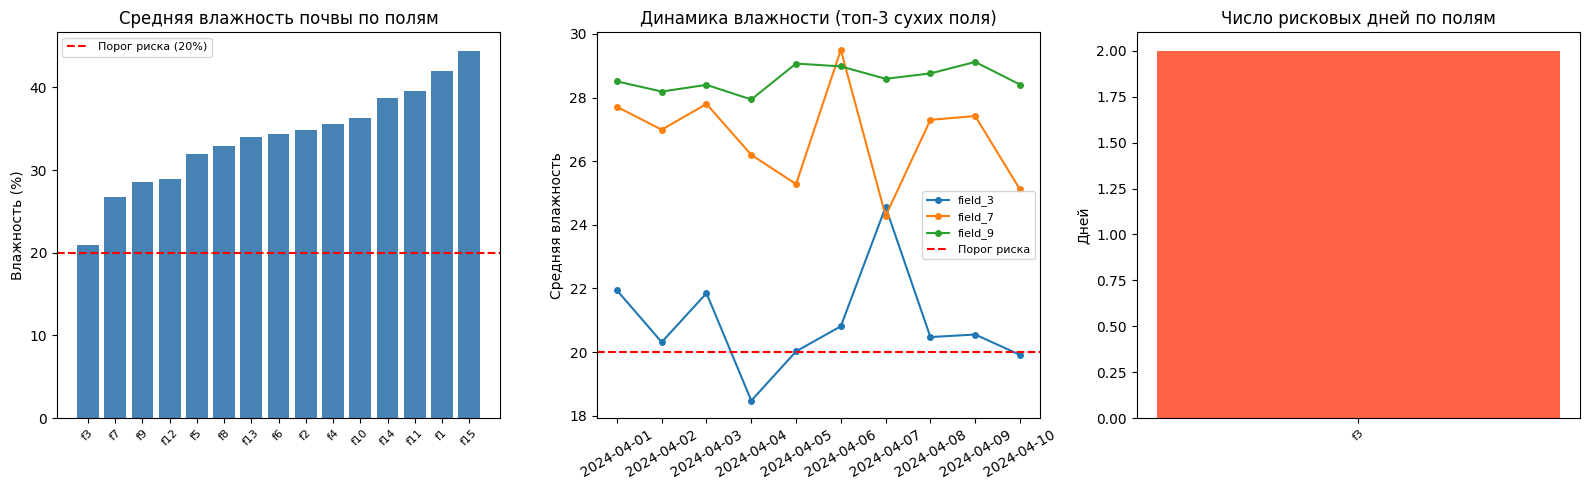

График сохранен в agro_analysis.png


In [28]:
# Собираем данные для визуализации
pdf_agg = agg_df.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Средняя влажность по полям (все дни)
field_avg = pdf_agg.groupby('field_id')['avg_moisture'].mean().sort_values()
colors = ['red' if v < 20 else 'steelblue' for v in field_avg.values]
axes[0].bar(range(len(field_avg)), field_avg.values, color=colors)
axes[0].axhline(20, color='red', linestyle='--', label='Порог риска (20%)')
axes[0].set_xticks(range(len(field_avg)))
axes[0].set_xticklabels(
    [f.replace('field_', 'f') for f in field_avg.index],
    rotation=45, fontsize=8
)
axes[0].set_title('Средняя влажность почвы по полям')
axes[0].set_ylabel('Влажность (%)')
axes[0].legend(fontsize=8)

# 2. Динамика влажности по дням для топ-3 сухих полей
driest_fields = field_avg.head(3).index.tolist()
for fid in driest_fields:
    sub = pdf_agg[pdf_agg['field_id'] == fid].sort_values('date')
    axes[1].plot(sub['date'], sub['avg_moisture'],
                 marker='o', markersize=4, label=fid)
axes[1].axhline(20, color='red', linestyle='--', label='Порог риска')
axes[1].set_title('Динамика влажности (топ-3 сухих поля)')
axes[1].set_ylabel('Средняя влажность')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)

# 3. Число рисковых дней по полям
risk_pdf = pdf_agg[pdf_agg['avg_moisture'] < 20] \
    .groupby('field_id').size().sort_values(ascending=False)
if len(risk_pdf) > 0:
    axes[2].bar(range(len(risk_pdf)), risk_pdf.values, color='tomato')
    axes[2].set_xticks(range(len(risk_pdf)))
    axes[2].set_xticklabels(
        [f.replace('field_', 'f') for f in risk_pdf.index],
        rotation=45, fontsize=8
    )
axes[2].set_title('Число рисковых дней по полям')
axes[2].set_ylabel('Дней')

plt.tight_layout()
plt.savefig('agro_analysis.png', dpi=100)
plt.show()
print('График сохранен в agro_analysis.png')

In [29]:
# Завершение работы SparkSession
spark.stop()
print('SparkSession остановлен.')

SparkSession остановлен.
